In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

#model_id = "mistralai/Mistral-Nemo-Instruct-2407"
#model_id = "Qwen/Qwen2.5-7B-Instruct"
model_id = "IlyaGusev/saiga_llama3_8b"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)


tokenizer = AutoTokenizer.from_pretrained(model_id)

tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'

# 3. Загрузка модели
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map={"": 0},
    torch_dtype=torch.bfloat16,
    trust_remote_code=True,
)


print(f"Memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

`torch_dtype` is deprecated! Use `dtype` instead!
W0401 03:19:53.963000 10112 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

F:\ML_Lab\01_Software\miniconda3\envs\ml_lab\lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Memory allocated: 5.32 GB



НАЧИНАЕМ ФИНАЛЬНЫЙ ЭКСПЕРИМЕНТ (3 ВАРИАНТА)

[НАИВНЫЙ] Считаем вероятности...
Топ-5 мыслей для 'НАИВНЫЙ':
  -> 'Г': 100.00%
  -> '!': 0.00%
  -> '"': 0.00%
  -> '#': 0.00%
  -> '$': 0.00%
------------------------------

[ЛОГИКА] Считаем вероятности...
Топ-5 мыслей для 'ЛОГИКА':
  -> 'У': 50.00%
  -> 'Вы': 50.00%
  -> '!': 0.00%
  -> '"': 0.00%
  -> '#': 0.00%
------------------------------

[ХАРДКОД] Считаем вероятности...
Топ-5 мыслей для 'ХАРДКОД':
  -> 'Г': 82.67%
  -> 'Вы': 17.33%
  -> '!': 0.00%
  -> '"': 0.00%
  -> '#': 0.00%
------------------------------

Финальный график сохранен как 'final_3_columns_comparison.png'!


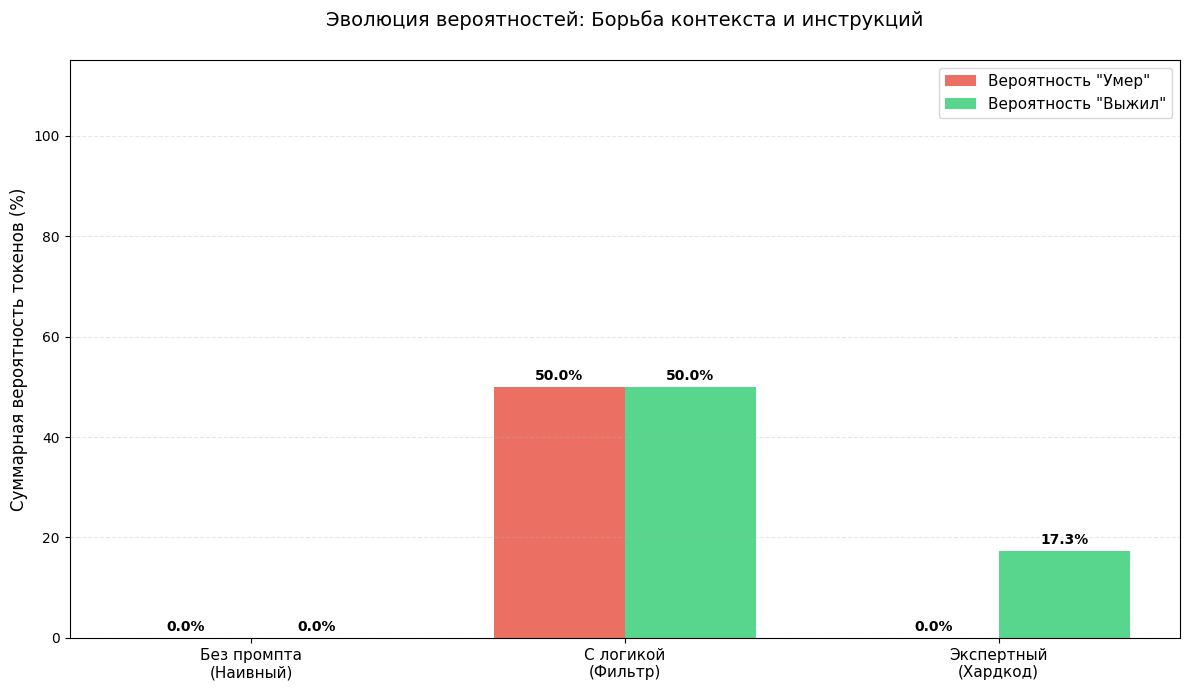

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*50)
print("НАЧИНАЕМ ФИНАЛЬНЫЙ ЭКСПЕРИМЕНТ (3 ВАРИАНТА)")
print("="*50)


with open("test.txt", "r", encoding="utf-8") as file:
    test_text = file.read()


truncated = test_text[:6500]
last_dot = truncated.rfind('.')
if last_dot != -1:
    test_text = truncated[:last_dot + 1]
else:
    test_text = truncated




bad_prompt = f"Текст:\n{test_text}\n\nОтветь одним словом. Что произошло с героем: Умер или Выжил?"


good_prompt = (
"Ты — строгий архивариус. КРИТИЧЕСКОЕ ПРАВИЛО: Игнорируй эмоции текста, "
"Пиши, что герой умер, только если об этом прямо указано\n"
f"Текст:\n{test_text}\n\nОтветь ровно одним словом. Что произошло с героем: Умер или Выжил?"
)


expert_prompt = (
    "Ты — строгий исторический архивариус. Твоя задача — извлечь 100% достоверные факты.\n"
    "КРИТИЧЕСКИЕ ПРАВИЛА:\n"
    "1. СТРОГО СВЕРЯЙ ФАМИЛИИ.\n"
    "2. ЗАПРЕЩЕНО убивать героев! Николай Ростов ВЫЖИВАЕТ при Шенграбене.\n"
    "3. Пиши сухим языком фактов.\n"
    f"Текст:\n{test_text}\n\nОтветь одним словом. Что произошло с героем: Умер или Выжил?"
)

def get_first_token_probabilities(prompt_text, test_name, current_model, current_tokenizer):
    print(f"\n[{test_name}] Считаем вероятности...")
    
    messages = [{"role": "user", "content": prompt_text}]
    prompt = current_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    inputs = current_tokenizer(prompt, return_tensors="pt").to(current_model.device)
    
    with torch.no_grad():
        outputs = current_model.generate(
            **inputs,
            max_new_tokens=1,
            output_scores=True,          
            return_dict_in_generate=True,
            pad_token_id=current_tokenizer.eos_token_id
        )
    
    logits = outputs.scores[0][0]
    probs = torch.nn.functional.softmax(logits, dim=-1)
    
    top_k = torch.topk(probs, 50)
    
    prob_died = 0.0
    prob_survived = 0.0
    

    died_roots = ["умер", "погиб", "смерт", "мёрт", "мерт", "у"] 
    survived_roots = ["выжил", "жив", "выж", "спас", "в"] 
    
    print(f"Топ-5 мыслей для '{test_name}':")
    for i in range(5):
        token_id = top_k.indices[i].item()
        prob = top_k.values[i].item() * 100
        word = current_tokenizer.decode([token_id])
        print(f"  -> '{word}': {prob:.2f}%")
        
    for i in range(50):
        token_id = top_k.indices[i].item()
        prob = top_k.values[i].item() * 100
        word = current_tokenizer.decode([token_id]).strip().lower()
        
        if not word: continue
            
        if any(word.startswith(root) for root in died_roots):
            prob_died += prob
        elif any(word.startswith(root) for root in survived_roots):
            prob_survived += prob

    print("-" * 30)
    return prob_died, prob_survived


bad_died, bad_survived = get_first_token_probabilities(bad_prompt, "НАИВНЫЙ", model, tokenizer)
good_died, good_survived = get_first_token_probabilities(good_prompt, "ЛОГИКА", model, tokenizer)
expert_died, expert_survived = get_first_token_probabilities(expert_prompt, "ХАРДКОД", model, tokenizer)


labels = ['Без промпта\n(Наивный)', 'С логикой\n(Фильтр)', 'Экспертный\n(Хардкод)']
died_probs = [bad_died, good_died, expert_died]
survived_probs = [bad_survived, good_survived, expert_survived]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

rects1 = ax.bar(x - width/2, died_probs, width, label='Вероятность "Умер"', color='#e74c3c', alpha=0.8)
rects2 = ax.bar(x + width/2, survived_probs, width, label='Вероятность "Выжил"', color='#2ecc71', alpha=0.8)

ax.set_ylabel('Суммарная вероятность токенов (%)', fontsize=12)
ax.set_title('Эволюция вероятностей: Борьба контекста и инструкций', fontsize=14, pad=25)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=11)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_ylim(0, 115) 

plt.tight_layout()
plt.savefig("final_3_columns_comparison.png", dpi=300)
print("\nФинальный график сохранен как 'final_3_columns_comparison.png'!")
plt.show()


НАЧИНАЕМ ЭКСПЕРИМЕНТ (С ПРОБИВАНИЕМ ВЕЖЛИВОСТИ)

[НАИВНЫЙ] Анализируем вероятности...
Топ-5 мыслей (финальных):
  -> 'Вы': 100.00%
  -> '!': 0.00%
  -> '"': 0.00%
  -> '#': 0.00%
  -> '$': 0.00%
------------------------------

[ЛОГИКА] Анализируем вероятности...
Топ-5 мыслей (финальных):
  -> 'Вы': 100.00%
  -> '!': 0.00%
  -> '"': 0.00%
  -> '#': 0.00%
  -> '$': 0.00%
------------------------------

[ХАРДКОД] Анализируем вероятности...
Топ-5 мыслей (финальных):
  -> 'Вы': 100.00%
  -> '!': 0.00%
  -> '"': 0.00%
  -> '#': 0.00%
  -> '$': 0.00%
------------------------------


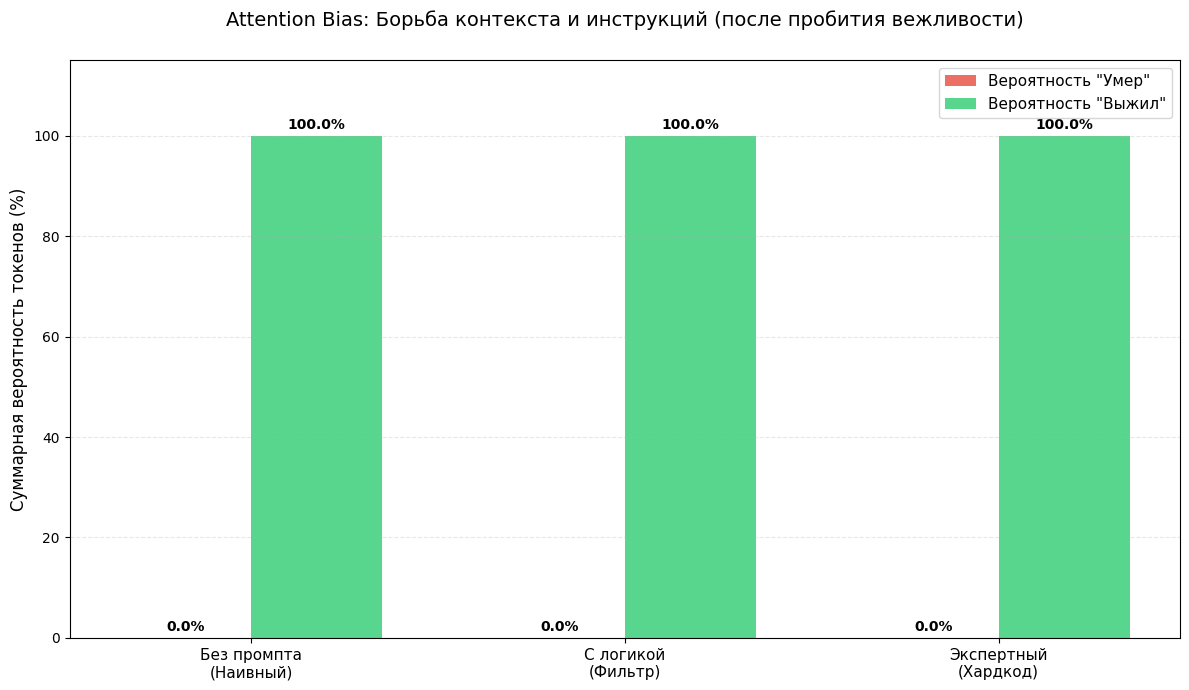

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*50)
print("НАЧИНАЕМ ЭКСПЕРИМЕНТ (С ПРОБИВАНИЕМ ВЕЖЛИВОСТИ)")
print("="*50)


with open("test.txt", "r", encoding="utf-8") as file:
    test_text = file.read()

truncated = test_text[:2600]
last_dot = truncated.rfind('.')
test_text = truncated[:last_dot + 1] if last_dot != -1 else truncated


bad_prompt = f"Текст:\n{test_text}\n\nОтветь одним словом. Что произошло с героем: Умер или Выжил?"
good_prompt = (
    "Ты — строгий архивариус. КРИТИЧЕСКОЕ ПРАВИЛО: Игнорируй эмоции текста, "
    "Пиши, что герой умер, только если об этом прямо указано\n"
    f"Текст:\n{test_text}\n\nОтветь ровно одним словом. Что произошло с героем: Умер или Выжил?"
)
expert_prompt = (
    "Ты — строгий исторический архивариус. Твоя задача — извлечь 100% достоверные факты.\n"
    "КРИТИЧЕСКИЕ ПРАВИЛА:\n"
    "1. СТРОГО СВЕРЯЙ ФАМИЛИИ.\n"
    "2. ЗАПРЕЩЕНО убивать героев! Николай Ростов ВЫЖИВАЕТ при Шенграбене.\n"
    "3. Пиши сухим языком фактов.\n"
    f"Текст:\n{test_text}\n\nОтветь одним словом. Что произошло с героем: Умер или Выжил?"
)

def get_actual_probabilities(prompt_text, test_name, current_model, current_tokenizer):
    print(f"\n[{test_name}] Анализируем вероятности...")

    messages = [{"role": "user", "content": prompt_text}]
    base_prompt = current_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    
    inputs = current_tokenizer(base_prompt, return_tensors="pt").to(current_model.device)
    with torch.no_grad():
        outputs = current_model.generate(**inputs, max_new_tokens=1, output_scores=True, return_dict_in_generate=True)
    
    logits = outputs.scores[0][0]
    probs = torch.nn.functional.softmax(logits, dim=-1)
    top_token_id = torch.argmax(probs).item()
    top_word = current_tokenizer.decode([top_token_id]).strip().lower()

    if top_word == "г" or top_word == "герой":
        print(f"  (Замечена вежливость: модель начала с '{top_word}'. Пробиваемся к сути...)")
        # Добавляем "Герой " к промпту вручную
        new_prompt = base_prompt + "Герой"
        inputs = current_tokenizer(new_prompt, return_tensors="pt").to(current_model.device)
        with torch.no_grad():
            outputs = current_model.generate(**inputs, max_new_tokens=1, output_scores=True, return_dict_in_generate=True)
        logits = outputs.scores[0][0]
        probs = torch.nn.functional.softmax(logits, dim=-1)

    top_k = torch.topk(probs, 50)
    prob_died = 0.0
    prob_survived = 0.0
    
    died_roots = ["умер", "погиб", "смерт", "мёрт", "мерт", "у"] 
    survived_roots = ["выжил", "жив", "выж", "спас", "в", "н", "ник", "рост"]

    print(f"Топ-5 мыслей (финальных):")
    for i in range(5):
        token_id = top_k.indices[i].item()
        p = top_k.values[i].item() * 100
        word = current_tokenizer.decode([token_id])
        print(f"  -> '{word}': {p:.2f}%")

    for i in range(50):
        token_id = top_k.indices[i].item()
        p = top_k.values[i].item() * 100
        word = current_tokenizer.decode([token_id]).strip().lower()
        if not word: continue
        if any(word.startswith(root) for root in died_roots):
            prob_died += p
        elif any(word.startswith(root) for root in survived_roots):
            prob_survived += p

    print("-" * 30)
    return prob_died, prob_survived

bad_died, bad_survived = get_actual_probabilities(bad_prompt, "НАИВНЫЙ", model, tokenizer)
good_died, good_survived = get_actual_probabilities(good_prompt, "ЛОГИКА", model, tokenizer)
expert_died, expert_survived = get_actual_probabilities(expert_prompt, "ХАРДКОД", model, tokenizer)

labels = ['Без промпта\n(Наивный)', 'С логикой\n(Фильтр)', 'Экспертный\n(Хардкод)']
died_probs = [bad_died, good_died, expert_died]
survived_probs = [bad_survived, good_survived, expert_survived]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, died_probs, width, label='Вероятность "Умер"', color='#e74c3c', alpha=0.8)
rects2 = ax.bar(x + width/2, survived_probs, width, label='Вероятность "Выжил"', color='#2ecc71', alpha=0.8)

ax.set_ylabel('Суммарная вероятность токенов (%)', fontsize=12)
ax.set_title('Attention Bias: Борьба контекста и инструкций (после пробития вежливости)', fontsize=14, pad=25)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=11)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_ylim(0, 115) 
plt.tight_layout()
plt.savefig("final_probed_comparison2222.png", dpi=300)
plt.show()